# RFECV/STABL manuscript panels: two main-figure variants and full supplementary figure

This notebook builds two 170 mm main-figure options and one 170 mm supplementary panel using only the intended feature-selection frameworks:

- STABL
- XGBoost + RFECV
- SVM + RFECV

GA-related material is intentionally excluded.

Main Figure Option 1 is F1-centered: **A = F1-score heatmap**, **B = F1-score versus selected feature count**, **C = STABL support**, and **D = cross-method consensus**.

Main Figure Option 2 is AUC-centered: **A = micro-average AUC heatmap**, **B = macro-average AUC versus selected feature count**, **C = STABL support**, and **D = cross-method consensus**.

Supplementary Figure S1 contains the full method-level performance summary: precision, recall, F1-score, micro-average AUC, macro-average AUC, and selected feature count.


In [8]:
# ============================================================
# 0. Imports, paths, and paper-style settings
# ============================================================
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=UserWarning)

# Run this notebook from code/ or from the project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "code" else Path.cwd()
OUT_DIR = PROJECT_ROOT / "Main_Figure_RFECV_STABL_TwoVersions_170mm"
SUPP_DIR = PROJECT_ROOT / "Supplementary_RFECV_STABL_AllMetrics_170mm"
TABLE_DIR = OUT_DIR / "tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SUPP_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MM_TO_INCH = 1 / 25.4
FIG_W_170MM = 170 * MM_TO_INCH

# Editable text in vector graphics.
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["axes.linewidth"] = 0.75
mpl.rcParams["xtick.major.width"] = 0.75
mpl.rcParams["ytick.major.width"] = 0.75
mpl.rcParams["xtick.major.size"] = 2.5
mpl.rcParams["ytick.major.size"] = 2.5

TISSUE_ORDER = ["A", "G", "H"]
TISSUE_LABELS = {"A": "Tissue A", "G": "Tissue G", "H": "Tissue H"}
OMICS_ORDER = ["Protein", "RNA + Protein"]
FULL_OMICS_ORDER = ["Protein", "RNA", "RNA + Protein"]
METHOD_ORDER = ["STABL", "XGBoost + RFECV", "SVM + RFECV"]
MAIN_METHOD_ORDER = ["STABL", "XGBoost + RFECV"]
METRIC_ORDER = ["Precision", "Recall", "F1-score"]

METHOD_SHORT = {
    "STABL": "STABL",
    "XGBoost + RFECV": "XGB+RFECV",
    "SVM + RFECV": "SVM+RFECV",
}
MODALITY_SHORT = {"Protein": "Protein", "RNA": "RNA", "RNA + Protein": "Protein + RNA"}

COLORS = {
    "Protein": "#4E79A7",
    "RNA": "#59A14F",
    "RNA + Protein": "#F28E2B",
    "STABL": "#E15759",
    "XGBoost + RFECV": "#4E79A7",
    "SVM + RFECV": "#6D6D6D",
}

MARKERS = {"Protein": "o", "RNA": "^", "RNA + Protein": "s"}


def save_figure(fig, stem, out_dir=OUT_DIR, dpi=600):
    """Save a figure as PNG, SVG, and PDF."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for ext in ["png", "svg", "pdf"]:
        path = out_dir / f"{stem}.{ext}"
        fig.savefig(path, dpi=dpi, bbox_inches="tight", pad_inches=0.035)
        paths.append(path)
    return paths


def panel_label(ax, label, x=-0.10, y=1.04):
    """Only top-level panel labels are bolded."""
    ax.text(x, y, f"({label})", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9.5, fontweight="bold")


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=7)


def final_style(fig):
    """Keep all non-panel-label text normal weight."""
    for ax in fig.axes:
        ax.title.set_fontweight("normal")
        ax.xaxis.label.set_fontweight("normal")
        ax.yaxis.label.set_fontweight("normal")
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight("normal")

In [9]:
# ============================================================
# 1. Curated performance table
# ============================================================
# Values are manually curated from the current project figures/results.
# Main figure uses STABL and XGBoost + RFECV for predictive-performance panels.
# SVM + RFECV is retained in the full table and moved to the supplementary performance panel.

results = [
    # ---------------- STABL ----------------
    ["STABL", "A", "Protein", None, 0.687, 0.717, 0.437, 0.600, 0.499],
    ["STABL", "A", "RNA", None, 0.446, 0.428, 0.070, 0.225, 0.107],
    ["STABL", "A", "RNA + Protein", None, 0.578, 0.653, 0.487, 0.400, 0.306],
    ["STABL", "G", "Protein", None, 0.322, 0.324, 0.015, 0.025, 0.019],
    ["STABL", "G", "RNA", None, 0.537, 0.496, 0.214, 0.250, 0.231],
    ["STABL", "G", "RNA + Protein", None, 0.334, 0.344, 0.153, 0.075, 0.077],
    ["STABL", "H", "Protein", None, 0.327, 0.341, 0.066, 0.075, 0.070],
    ["STABL", "H", "RNA", None, 0.841, 0.842, 0.646, 0.550, 0.534],
    ["STABL", "H", "RNA + Protein", None, 0.534, 0.513, 0.168, 0.250, 0.198],

    # ---------------- XGBoost + RFECV ----------------
    ["XGBoost + RFECV", "A", "Protein", 3, 0.749, 0.778, 0.480, 0.625, 0.539],
    ["XGBoost + RFECV", "A", "RNA", 14, 0.549, 0.575, 0.586, 0.425, 0.361],
    ["XGBoost + RFECV", "A", "RNA + Protein", 17, 0.716, 0.766, 0.576, 0.650, 0.598],
    ["XGBoost + RFECV", "G", "Protein", 4, 0.287, 0.341, 0.190, 0.100, 0.127],
    ["XGBoost + RFECV", "G", "RNA", 13, 0.612, 0.653, 0.375, 0.325, 0.294],
    ["XGBoost + RFECV", "G", "RNA + Protein", 17, 0.463, 0.431, 0.155, 0.150, 0.143],
    ["XGBoost + RFECV", "H", "Protein", 4, 0.799, 0.829, 0.727, 0.625, 0.575],
    ["XGBoost + RFECV", "H", "RNA", 14, 0.719, 0.692, 0.340, 0.350, 0.338],
    ["XGBoost + RFECV", "H", "RNA + Protein", 18, 0.765, 0.742, 0.488, 0.600, 0.532],

    # ---------------- SVM + RFECV ----------------
    ["SVM + RFECV", "A", "Protein", 4, 0.346, 0.338, 0.115, 0.150, 0.130],
    ["SVM + RFECV", "A", "RNA", 5, 0.463, 0.450, 0.208, 0.325, 0.233],
    ["SVM + RFECV", "A", "RNA + Protein", 9, 0.326, 0.272, 0.060, 0.050, 0.048],
    ["SVM + RFECV", "G", "Protein", 2, 0.291, 0.321, 0.250, 0.025, 0.045],
    ["SVM + RFECV", "G", "RNA", 14, 0.688, 0.742, 0.417, 0.400, 0.334],
    ["SVM + RFECV", "G", "RNA + Protein", 16, 0.471, 0.418, 0.170, 0.175, 0.137],
    ["SVM + RFECV", "H", "Protein", 5, 0.340, 0.360, 0.000, 0.000, 0.000],
    ["SVM + RFECV", "H", "RNA", 13, 0.801, 0.800, 0.582, 0.600, 0.549],
    ["SVM + RFECV", "H", "RNA + Protein", 18, 0.517, 0.532, 0.151, 0.225, 0.180],
]

results_df = pd.DataFrame(
    results,
    columns=["method", "tissue", "modality", "d", "micro_auc", "macro_auc", "precision", "recall", "f1"],
)
results_df["tissue_label"] = results_df["tissue"].map(TISSUE_LABELS)
results_df["method_short"] = results_df["method"].map(METHOD_SHORT)
results_df["modality_short"] = results_df["modality"].map(MODALITY_SHORT)
results_df.to_csv(TABLE_DIR / "curated_model_performance_table.csv", index=False)
results_df.head()

,method,tissue,modality,d,micro_auc,macro_auc,precision,recall,f1,tissue_label,method_short,modality_short
0,STABL,A,Protein,NaN,0.687,0.717,0.437,0.600,0.499,Tissue A,STABL,Protein
1,STABL,A,RNA,NaN,0.446,0.428,0.070,0.225,0.107,Tissue A,STABL,RNA
2,STABL,A,RNA + Protein,NaN,0.578,0.653,0.487,0.400,0.306,Tissue A,STABL,Protein + RNA
3,STABL,G,Protein,NaN,0.322,0.324,0.015,0.025,0.019,Tissue G,STABL,Protein
4,STABL,G,RNA,NaN,0.537,0.496,0.214,0.250,0.231,Tissue G,STABL,RNA


In [10]:
# ============================================================
# Selected feature sets
# ============================================================

xgb_rfecv_sets = {
    ("A", "Protein"): [
        "XP_006562449", "NP_001035311", "NP_001014992",
    ],
    ("A", "RNA"): [
        "LOC100577472", "LOC100576401", "LOC411734", "LOC113218651",
        "Cox6b1", "LOC414001", "LOC100577242", "LOC107963984",
        "LOC409353", "LOC724700", "LOC102655281", "LOC100577341",
        "Ecr", "LOC408556",
    ],
    ("G", "Protein"): [
        "NP_001116485", "XP_006559651", "NP_001011598", "XP_006561354",
    ],
    ("G", "RNA"): [
        "LOC113218814", "LOC725197", "LOC100578253", "LOC100577746",
        "LOC100302106", "LOC100577000", "LOC412175", "Arp1", "Cox6b1",
        "LOC100577959", "LOC724169", "LOC100576544", "LOC724488",
    ],
    ("H", "Protein"): [
        "NP_001229365", "NP_001014994", "XP_026297257", "XP_001121500",
    ],
    ("H", "RNA"): [
        "LOC100578953", "LOC102656166", "LOC410351", "LOC552206",
        "LOC409475", "LOC408677", "LOC100576522", "LOC107964193",
        "LOC100578925", "LOC408546", "LOC409470", "LOC100578739",
        "LOC113218778", "LOC408282",
    ],
}

stabl_sets = {
    ("A", "Protein"): [
        "prot__XP_006567799", "XP_396012", "XP_001122470", "XP_006565473",
        "XP_026297057", "XP_396143", "XP_006561186", "XP_006572357",
        "XP_006561423", "XP_006558043", "XP_026296829", "XP_016772668",
        "XP_006562002", "XP_026298544", "XP_006569870", "XP_006563448",
        "NP_001128140", "XP_006570209", "XP_006570154", "XP_006566821",
        "NP_001014992", "XP_026298830", "XP_001120350", "XP_001121736",
        "XP_026301434", "XP_003251558", "XP_001120618", "XP_006564133",
        "XP_001122245", "XP_026297433", "XP_026297680",
    ],
    ("A", "RNA"): [
        "rna__LOC113218861", "LOC413101", "LOC100576679", "LOC725255",
        "Kakusei", "LOC102656039", "LOC552572", "LOC411602",
        "LOC113218653", "Mir9884", "LOC552192", "LOC113218848",
        "LOC113218735", "LOC113218582", "LOC413693", "LOC725191",
        "LOC412401", "LOC113218737", "LOC550918", "LOC411856",
        "LOC412602", "LOC552081", "LOC102654517", "LOC409765",
        "LOC413858", "LOC102653584",
    ],
    ("G", "Protein"): [
        "prot__XP_623499", "XP_026301924", "XP_003251482", "XP_006566068",
        "XP_026301542", "XP_026298830", "XP_016772668", "XP_003250512",
        "XP_003249681", "XP_006559175", "XP_006561354", "XP_006568004",
        "XP_001120184", "XP_026298720", "XP_006558978", "XP_006564938",
        "XP_003251850", "XP_026296479",
    ],
    ("G", "RNA"): [
        "rna__LOC414037", "LOC100576221", "LOC102653858",
    ],
    ("H", "Protein"): [
        "prot__XP_003250976", "XP_001121500", "XP_026297257", "XP_396217",
        "XP_001121251", "XP_026295519", "XP_006569730", "XP_006563018",
        "XP_006564795",
    ],
    ("H", "RNA"): [
        "rna__LOC725901", "LOC410019", "LOC413362", "LOC551454",
        "LOC102653997", "LOC113219115", "LOC412254", "Gpdh",
        "LOC113219098", "LOC411980", "LOC102654768", "LOC409346",
        "LOC100576590", "LOC414032",
    ],
}

svm_rfecv_sets = {
    ("A", "Protein"): [
        "XP_006567799", "XP_016770991", "XP_001122470", "NP_001011589",
    ],
    ("A", "RNA"): [
        "LOC409589", "LOC408968", "LOC113219106", "LOC726509", "LOC107963984",
    ],
    ("G", "Protein"): [
        "XP_026301924", "XP_016770991",
    ],
    ("G", "RNA"): [
        "LOC100577746", "LOC727405", "LOC113218582", "LOC100576104",
        "LOC412371", "LOC414037", "LOC409968", "LOC113219149",
        "LOC409326", "LOC724280", "LOC412721", "LOC102655698",
        "LOC726377", "LOC410664",
    ],
    ("H", "Protein"): [
        "XP_001121500", "XP_003250976", "XP_026297257",
        "XP_006558043", "XP_001120618",
    ],
    ("H", "RNA"): [
        "LOC725901", "LOC412254", "Gpdh", "LOC113219115",
        "LOC102653997", "LOC552485", "LOC100578726", "LOC551225",
        "LOC411837", "LOC410517", "LOC413619", "LOC100576384",
        "LOC411980",
    ],
}

def canonical_feature_id(x):
    """Remove modality prefixes and simple transcript/protein suffix artifacts."""
    s = str(x).strip()
    s = re.sub(r"^(prot__|rna__|prot_|rna_|protein__|protein_|transcript__|transcript_)", "", s, flags=re.IGNORECASE)
    s = s.split()[0].strip()
    s = re.sub(r"\.\d+$", "", s)
    return s

def clean_feature_set(values):
    return set(canonical_feature_id(v) for v in values if str(v).strip())

def add_union_feature_sets(raw_sets):
    """Add RNA + Protein as a union of the protein and RNA sets for each tissue."""
    out = {}
    for key, values in raw_sets.items():
        out[key] = clean_feature_set(values)
    for tissue in TISSUE_ORDER:
        out[(tissue, "RNA + Protein")] = out[(tissue, "Protein")] | out[(tissue, "RNA")]
    return out

method_sets = {
    "STABL": add_union_feature_sets(stabl_sets),
    "XGBoost + RFECV": add_union_feature_sets(xgb_rfecv_sets),
    "SVM + RFECV": add_union_feature_sets(svm_rfecv_sets),
}

categories = [(t, o) for t in TISSUE_ORDER for o in OMICS_ORDER]
category_labels = [f"{t}-{o.replace('RNA + Protein', 'R+P').replace('Protein', 'P')}" for t, o in categories]

# Check that only the intended method labels are used.
assert set(method_sets.keys()) == set(METHOD_ORDER)

In [11]:
# ============================================================
# 3. Feature-selection summary tables
# ============================================================
# Feature-count tables are computed for all three omics settings.
# Main panels still use OMICS_ORDER = [Protein, RNA + Protein],
# while the supplementary panel uses FULL_OMICS_ORDER.
size_rows = []
for method in METHOD_ORDER:
    for tissue in TISSUE_ORDER:
        for modality in FULL_OMICS_ORDER:
            if (tissue, modality) in method_sets[method]:
                s = method_sets[method][(tissue, modality)]
                size_rows.append({
                    "method": method,
                    "tissue": tissue,
                    "modality": modality,
                    "feature_count": len(s),
                })
size_df = pd.DataFrame(size_rows)
size_df.to_csv(TABLE_DIR / "feature_set_sizes.csv", index=False)

# Use selected feature-list counts where available; otherwise keep the curated d value.
feature_count_lookup = size_df.set_index(["method", "tissue", "modality"])["feature_count"].to_dict()
results_df["d_plot"] = results_df.apply(
    lambda r: feature_count_lookup.get((r["method"], r["tissue"], r["modality"]), r["d"]),
    axis=1,
)

support_rows = []
for tissue in TISSUE_ORDER:
    for modality in OMICS_ORDER:
        stabl = method_sets["STABL"][(tissue, modality)]
        for method in ["XGBoost + RFECV", "SVM + RFECV"]:
            selected = method_sets[method][(tissue, modality)]
            overlap = selected & stabl
            support_rows.append({
                "tissue": tissue,
                "modality": modality,
                "method": method,
                "overlap_with_stabl": len(overlap),
                "selected_by_method": len(selected),
                "stabl_supported_fraction": len(overlap) / len(selected) if len(selected) else np.nan,
            })
support_df = pd.DataFrame(support_rows)
support_df.to_csv(TABLE_DIR / "rfecv_overlap_with_stabl.csv", index=False)

consensus_rows = []
for tissue in TISSUE_ORDER:
    for modality in OMICS_ORDER:
        sets = [method_sets[m][(tissue, modality)] for m in METHOD_ORDER]
        union = set().union(*sets)
        counts = {1: 0, 2: 0, 3: 0}
        for feature in union:
            k = sum(feature in s for s in sets)
            counts[k] += 1
        consensus_rows.append({
            "tissue": tissue,
            "modality": modality,
            "selected_by_1_method": counts[1],
            "selected_by_2_methods": counts[2],
            "selected_by_3_methods": counts[3],
            "union_size": len(union),
        })
consensus_df = pd.DataFrame(consensus_rows)
consensus_df.to_csv(TABLE_DIR / "consensus_tiers.csv", index=False)

jaccard_rows = []
for tissue in TISSUE_ORDER:
    for modality in OMICS_ORDER:
        for i, m1 in enumerate(METHOD_ORDER):
            for m2 in METHOD_ORDER[i+1:]:
                s1 = method_sets[m1][(tissue, modality)]
                s2 = method_sets[m2][(tissue, modality)]
                union = s1 | s2
                inter = s1 & s2
                jaccard_rows.append({
                    "tissue": tissue,
                    "modality": modality,
                    "method_1": m1,
                    "method_2": m2,
                    "intersection": len(inter),
                    "union": len(union),
                    "jaccard": len(inter) / len(union) if len(union) else np.nan,
                })
jaccard_df = pd.DataFrame(jaccard_rows)
jaccard_df.to_csv(TABLE_DIR / "pairwise_jaccard_indices.csv", index=False)

size_df.head(), support_df.head(), consensus_df.head()


(  method tissue       modality  feature_count
 0  STABL      A        Protein             31
 1  STABL      A            RNA             26
 2  STABL      A  RNA + Protein             57
 3  STABL      G        Protein             18
 4  STABL      G            RNA              3,
   tissue       modality           method  overlap_with_stabl  \
 0      A        Protein  XGBoost + RFECV                   1   
 1      A        Protein      SVM + RFECV                   2   
 2      A  RNA + Protein  XGBoost + RFECV                   1   
 3      A  RNA + Protein      SVM + RFECV                   2   
 4      G        Protein  XGBoost + RFECV                   1   
 
    selected_by_method  stabl_supported_fraction  
 0                   3                  0.333333  
 1                   4                  0.500000  
 2                  17                  0.058824  
 3                   9                  0.222222  
 4                   4                  0.250000  ,
   tissue       mo

In [12]:

# ============================================================
# 4. Main and supplementary plotting functions
# ============================================================
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# Colorblind-friendly manuscript palettes.
F1_CMAP = LinearSegmentedColormap.from_list(
    "f1_blue",
    ["#F7FBFF", "#DEEBF7", "#9ECAE1", "#4292C6", "#08519C"]
)
AUC_CMAP = LinearSegmentedColormap.from_list(
    "auc_purple",
    ["#FCFBFD", "#EFEDF5", "#BCBDDC", "#807DBA", "#54278F"]
)
SUPPORT_CMAP = LinearSegmentedColormap.from_list(
    "support_orange",
    ["#FFF7EC", "#FDD49E", "#FDBB84", "#EF6548", "#990000"]
)
FEATURE_CMAP = LinearSegmentedColormap.from_list(
    "feature_green",
    ["#F7FCF5", "#C7E9C0", "#74C476", "#238B45", "#00441B"]
)
CONSENSUS_COLORS = {
    "1 method": "#D8EAF2",
    "2 methods": "#74A9CF",
    "3 methods": "#045A8D",
}

METRIC_INFO = {
    "precision": ("Precision", "Precision", F1_CMAP, 0, 1.0),
    "recall": ("Recall", "Recall", F1_CMAP, 0, 1.0),
    "f1": ("F1-score", "F1-score", F1_CMAP, 0, 0.65),
    "micro_auc": ("Micro-average AUC", "Micro AUC", AUC_CMAP, 0, 1.0),
    "macro_auc": ("Macro-average AUC", "Macro AUC", AUC_CMAP, 0, 1.0),
    "d_plot": ("Selected feature count", "Features", FEATURE_CMAP, 0, None),
}


def _main_columns(modalities=OMICS_ORDER):
    cols = [(t, o) for t in TISSUE_ORDER for o in modalities]
    col_labels = [f"{t} · {'P' if o == 'Protein' else 'P+R' if o == 'RNA + Protein' else 'RNA'}" for t, o in cols]
    return cols, col_labels


def draw_metric_heatmap(ax, df, metric="f1", rows=MAIN_METHOD_ORDER, modalities=OMICS_ORDER,
                        label="A", title=None, vmax=None, cmap=None, show_cbar=True):
    """Generic heatmap for method × tissue/omics performance summaries."""
    panel_label(ax, label, x=-0.11, y=1.03)
    metric_title, cbar_label, default_cmap, vmin, default_vmax = METRIC_INFO[metric]
    if title is None:
        title = f"{metric_title} summary"
    if cmap is None:
        cmap = default_cmap
    if vmax is None:
        vmax = default_vmax if default_vmax is not None else float(np.nanmax(df[metric]))

    cols, col_labels = _main_columns(modalities)
    mat = np.full((len(rows), len(cols)), np.nan)
    for i, method in enumerate(rows):
        for j, (tissue, modality) in enumerate(cols):
            hit = df.query("method == @method and tissue == @tissue and modality == @modality")
            if len(hit):
                mat[i, j] = hit[metric].iloc[0]

    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    threshold = vmin + 0.64 * (vmax - vmin)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if np.isnan(val):
                label_text = "NA"
                txt_color = "#222222"
            else:
                label_text = f"{val:.3f}" if metric != "d_plot" else f"{int(round(val))}"
                txt_color = "white" if val > threshold else "#222222"
            ax.text(j, i, label_text, ha="center", va="center", fontsize=6.7, color=txt_color)

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=7)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([METHOD_SHORT[m] for m in rows], fontsize=7.2)
    ax.set_title(title, fontsize=8.0, pad=5, fontweight="normal")
    ax.set_xlabel("Tissue and omics setting", fontsize=7.2)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if show_cbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.025)
        cbar.ax.tick_params(labelsize=6, length=2)
        cbar.set_label(cbar_label, fontsize=6.7)
    return im


def draw_tradeoff_scatter_metric(ax, df, metric="f1", rows=MAIN_METHOD_ORDER, modalities=OMICS_ORDER,
                                 label="B", title=None, y_label=None):
    """Performance metric versus selected feature-set size."""
    panel_label(ax, label, x=-0.11, y=1.03)
    metric_title, _, _, _, default_vmax = METRIC_INFO[metric]
    if title is None:
        title = f"{metric_title}–sparsity trade-off"
    if y_label is None:
        y_label = metric_title

    sub = df[(df["method"].isin(rows)) & (df["modality"].isin(modalities))].copy()
    jitter = {"STABL": -0.35, "XGBoost + RFECV": 0.35, "SVM + RFECV": 0.0}

    for method in rows:
        for modality in modalities:
            msub = sub[(sub["method"] == method) & (sub["modality"] == modality)].copy()
            if msub.empty:
                continue
            xs = msub["d_plot"].astype(float) + jitter.get(method, 0.0)
            ys = msub[metric].astype(float)
            ax.scatter(
                xs, ys,
                s=50 if modality == "Protein" else 58,
                marker=MARKERS.get(modality, "o"),
                color=COLORS[method],
                edgecolor="white",
                linewidth=0.6,
                alpha=0.94,
                label=f"{METHOD_SHORT[method]} · {MODALITY_SHORT[modality]}",
            )
            for _, row in msub.iterrows():
                if not pd.isna(row["d_plot"]):
                    ax.text(
                        float(row["d_plot"]) + jitter.get(method, 0.0) + 0.55,
                        float(row[metric]) + 0.006,
                        row["tissue"],
                        fontsize=6.3,
                        ha="left",
                        va="center"
                    )

    ax.set_xlim(0, max(sub["d_plot"].dropna()) + 6)
    ymax = 1.0 if metric in ["micro_auc", "macro_auc", "precision", "recall"] else 0.66
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Selected feature count", fontsize=7.2)
    ax.set_ylabel(y_label, fontsize=7.2)
    ax.set_title(title, fontsize=8.0, pad=5, fontweight="normal")
    ax.grid(True, linestyle=":", linewidth=0.35, alpha=0.55)

    handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["STABL"],
               markeredgecolor="white", markersize=5.8, label="STABL"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["XGBoost + RFECV"],
               markeredgecolor="white", markersize=5.8, label="XGB+RFECV"),
        Line2D([0], [0], marker="o", color="0.25", markerfacecolor="0.25", linestyle="None",
               markersize=4.8, label="Protein"),
        Line2D([0], [0], marker="s", color="0.25", markerfacecolor="0.25", linestyle="None",
               markersize=4.8, label="Protein + RNA"),
    ]
    ax.legend(handles=handles, frameon=False, fontsize=6.0, loc="lower right", handlelength=1.1, borderpad=0.2)
    clean_axis(ax)


def draw_stabl_support_panel(ax, support_df, label="C"):
    """RFECV features supported by STABL."""
    panel_label(ax, label, x=-0.11, y=1.03)
    cats = [(t, o) for t in TISSUE_ORDER for o in OMICS_ORDER]
    cols = ["XGBoost + RFECV", "SVM + RFECV"]
    mat = np.zeros((len(cats), len(cols)))
    labels = []
    for yi, (tissue, modality) in enumerate(cats):
        row_labels = []
        for xi, method in enumerate(cols):
            row = support_df.query("tissue == @tissue and modality == @modality and method == @method").iloc[0]
            mat[yi, xi] = row["stabl_supported_fraction"]
            row_labels.append(f"{int(row['overlap_with_stabl'])}/{int(row['selected_by_method'])}")
        labels.append(row_labels)

    im = ax.imshow(mat, vmin=0, vmax=1, cmap=SUPPORT_CMAP, aspect="auto")
    for yi in range(mat.shape[0]):
        for xi in range(mat.shape[1]):
            val = mat[yi, xi]
            txt_color = "white" if val > 0.58 else "#222222"
            ax.text(xi, yi, f"{val:.2f}\n({labels[yi][xi]})", ha="center", va="center", fontsize=6.0, color=txt_color)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([METHOD_SHORT[c] for c in cols], rotation=25, ha="right", fontsize=6.6)
    ax.set_yticks(range(len(cats)))
    ax.set_yticklabels([f"{t} · {'P' if o == 'Protein' else 'P+R'}" for t, o in cats], fontsize=6.6)
    ax.set_title("RFECV features supported by STABL", fontsize=8.0, pad=5, fontweight="normal")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cbar.ax.tick_params(labelsize=6, length=2)
    cbar.set_label("Fraction", fontsize=6.7)


def draw_consensus_panel(ax, consensus_df, label="D"):
    """Consensus tiers across STABL, XGB+RFECV, and SVM+RFECV."""
    panel_label(ax, label, x=-0.11, y=1.03)
    cats = [(t, o) for t in TISSUE_ORDER for o in OMICS_ORDER]
    y = np.arange(len(cats))
    tiers = ["selected_by_1_method", "selected_by_2_methods", "selected_by_3_methods"]
    tier_labels = ["1 method", "2 methods", "3 methods"]
    tier_colors = [CONSENSUS_COLORS["1 method"], CONSENSUS_COLORS["2 methods"], CONSENSUS_COLORS["3 methods"]]
    left = np.zeros(len(cats))

    for tier, tier_label, color in zip(tiers, tier_labels, tier_colors):
        vals = []
        for tissue, modality in cats:
            vals.append(int(consensus_df.query("tissue == @tissue and modality == @modality")[tier].iloc[0]))
        ax.barh(y, vals, left=left, color=color, edgecolor="white", linewidth=0.45, label=tier_label)
        for yi, v, lft in zip(y, vals, left):
            if v > 0:
                ax.text(lft + v/2, yi, str(v), ha="center", va="center", fontsize=5.8,
                        color="white" if tier_label == "3 methods" else "#222222")
        left += np.array(vals)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{t} · {'P' if o == 'Protein' else 'P+R'}" for t, o in cats], fontsize=6.6)
    ax.invert_yaxis()
    ax.set_xlabel("Number of unique features", fontsize=7.0)
    ax.set_title("Consensus across selection methods", fontsize=8.0, pad=5, fontweight="normal")
    ax.legend(frameon=False, fontsize=6.0, loc="lower right", handlelength=1.1)
    ax.grid(axis="x", linestyle=":", linewidth=0.35, alpha=0.5)
    clean_axis(ax)


def draw_full_metric_heatmap(ax, df, metric, label, title=None, vmax=None):
    """Supplementary heatmap with all methods and all modalities."""
    panel_label(ax, label, x=-0.08, y=1.02)
    metric_title, cbar_label, cmap, vmin, default_vmax = METRIC_INFO[metric]
    if title is None:
        title = metric_title
    if vmax is None:
        vmax = default_vmax if default_vmax is not None else float(np.nanmax(df[metric]))

    cols = [(t, o) for t in TISSUE_ORDER for o in FULL_OMICS_ORDER]
    col_labels = [f"{t}-{MODALITY_SHORT[o].replace('Protein + RNA', 'P+R').replace('Protein', 'P')}" for t, o in cols]
    rows = METHOD_ORDER
    mat = np.full((len(rows), len(cols)), np.nan)
    for i, method in enumerate(rows):
        for j, (tissue, modality) in enumerate(cols):
            hit = df.query("method == @method and tissue == @tissue and modality == @modality")
            if len(hit):
                mat[i, j] = hit[metric].iloc[0]

    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
    threshold = vmin + 0.62 * (vmax - vmin)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if pd.isna(val):
                txt = "NA"
                color = "#222222"
            elif metric == "d_plot":
                txt = f"{int(round(val))}"
                color = "white" if val > threshold else "#222222"
            else:
                txt = f"{val:.2f}"
                color = "white" if val > threshold else "#222222"
            ax.text(j, i, txt, ha="center", va="center", fontsize=5.7, color=color)

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=38, ha="right", fontsize=6.1)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([METHOD_SHORT[m] for m in rows], fontsize=6.7)
    ax.set_title(title, fontsize=8.0, pad=5, fontweight="normal")
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    cbar = plt.colorbar(im, ax=ax, fraction=0.043, pad=0.021)
    cbar.ax.tick_params(labelsize=5.8, length=2)
    cbar.set_label(cbar_label, fontsize=6.1)


def draw_supplementary_feature_count_bars(ax, df, label="F"):
    """Alternative feature-count panel: all methods, grouped by tissue/omics."""
    panel_label(ax, label, x=-0.08, y=1.02)
    draw_full_metric_heatmap(ax, df, metric="d_plot", label=label, title="Selected feature count", vmax=float(np.nanmax(df["d_plot"])))


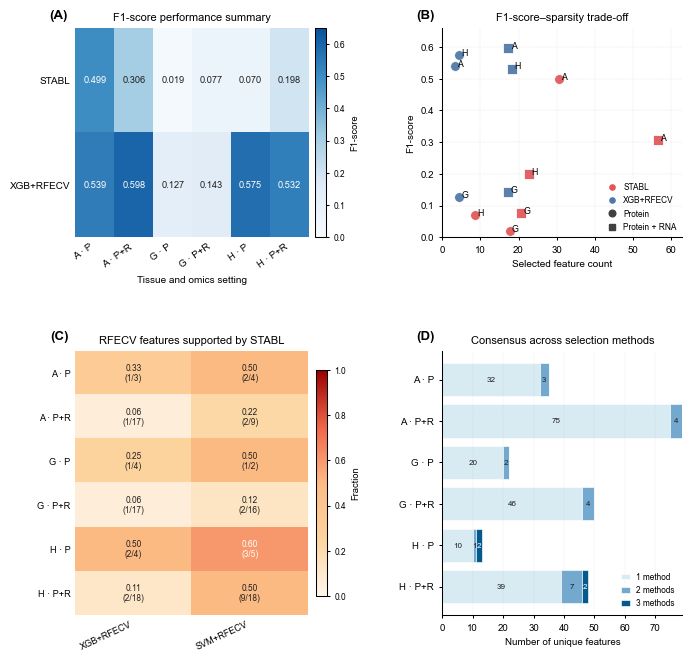

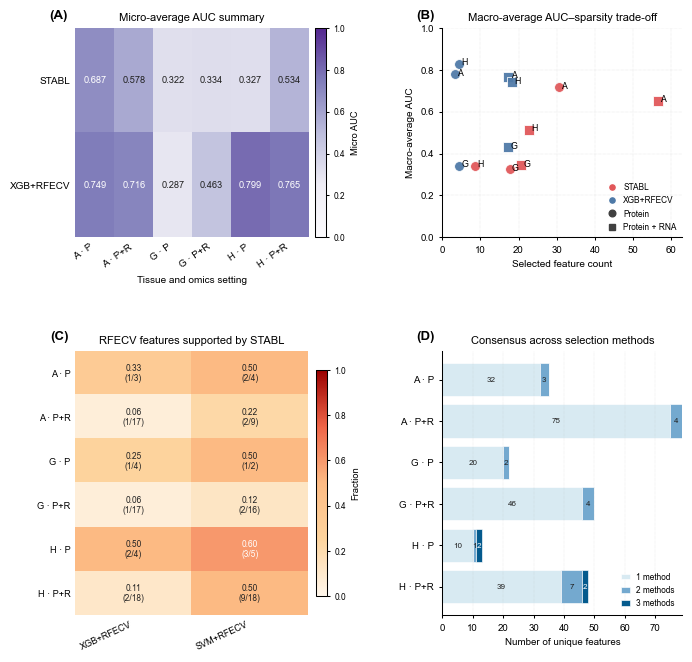

In [13]:

# ============================================================
# 5. Main 170 mm panels: two options
# ============================================================
def _make_main_template(stem, panel_a_metric, panel_b_metric, panel_a_title, panel_b_title):
    """Shared 170 mm main figure template."""
    fig = plt.figure(figsize=(FIG_W_170MM, 6.75), facecolor="white")
    outer = GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[0.95, 1.20],
        width_ratios=[1.10, 1.05],
        hspace=0.48,
        wspace=0.47,
        left=0.075,
        right=0.982,
        top=0.955,
        bottom=0.085,
    )

    ax_a = fig.add_subplot(outer[0, 0])
    ax_b = fig.add_subplot(outer[0, 1])
    ax_c = fig.add_subplot(outer[1, 0])
    ax_d = fig.add_subplot(outer[1, 1])

    draw_metric_heatmap(
        ax_a,
        results_df,
        metric=panel_a_metric,
        rows=MAIN_METHOD_ORDER,
        modalities=OMICS_ORDER,
        label="A",
        title=panel_a_title,
    )
    draw_tradeoff_scatter_metric(
        ax_b,
        results_df,
        metric=panel_b_metric,
        rows=MAIN_METHOD_ORDER,
        modalities=OMICS_ORDER,
        label="B",
        title=panel_b_title,
    )
    draw_stabl_support_panel(ax_c, support_df, label="C")
    draw_consensus_panel(ax_d, consensus_df, label="D")

    final_style(fig)
    save_figure(fig, stem, OUT_DIR)
    return fig


def make_main_figure_f1_centered():
    """Main Figure Option 1: both performance panels use F1-score."""
    return _make_main_template(
        stem="Figure1A_170mm_F1_centered_performance_sparsity_consensus",
        panel_a_metric="f1",
        panel_b_metric="f1",
        panel_a_title="F1-score performance summary",
        panel_b_title="F1-score–sparsity trade-off",
    )


def make_main_figure_auc_centered():
    """Main Figure Option 2: A uses micro-AUC and B uses macro-AUC."""
    return _make_main_template(
        stem="Figure1B_170mm_AUC_centered_micro_macro_sparsity_consensus",
        panel_a_metric="micro_auc",
        panel_b_metric="macro_auc",
        panel_a_title="Micro-average AUC summary",
        panel_b_title="Macro-average AUC–sparsity trade-off",
    )


main_fig_f1 = make_main_figure_f1_centered()
plt.show()

main_fig_auc = make_main_figure_auc_centered()
plt.show()


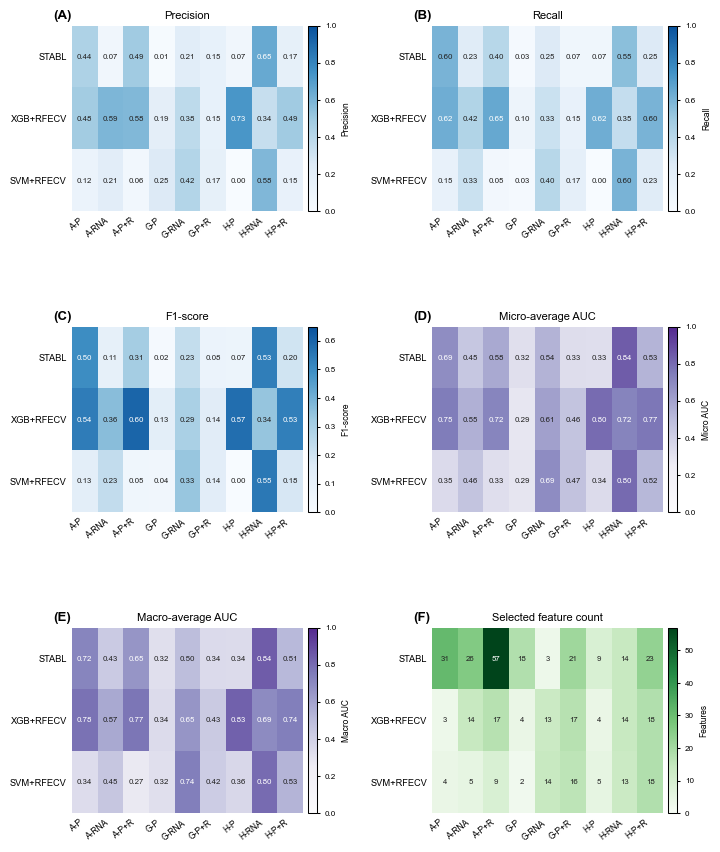

In [14]:

# ============================================================
# 6. Supplementary 170 mm panel: all metrics, all methods
# ============================================================
def make_full_supplementary_panel():
    """Create a 170 mm supplementary panel with full performance and feature-count summaries."""
    fig = plt.figure(figsize=(FIG_W_170MM, 8.85), facecolor="white")
    outer = GridSpec(
        3, 2,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0],
        width_ratios=[1.0, 1.0],
        hspace=0.62,
        wspace=0.46,
        left=0.075,
        right=0.982,
        top=0.965,
        bottom=0.075,
    )

    panels = [
        ("precision", "A", "Precision"),
        ("recall", "B", "Recall"),
        ("f1", "C", "F1-score"),
        ("micro_auc", "D", "Micro-average AUC"),
        ("macro_auc", "E", "Macro-average AUC"),
        ("d_plot", "F", "Selected feature count"),
    ]

    for idx, (metric, label, title) in enumerate(panels):
        ax = fig.add_subplot(outer[idx // 2, idx % 2])
        draw_full_metric_heatmap(
            ax,
            results_df,
            metric=metric,
            label=label,
            title=title,
            vmax=float(np.nanmax(results_df[metric])) if metric == "d_plot" else None,
        )

    final_style(fig)
    save_figure(fig, "Supplementary_Figure_S1_170mm_all_methods_all_metrics", SUPP_DIR)
    return fig


supp_fig_all = make_full_supplementary_panel()
plt.show()


# Suggested figure text

**Main Figure Option 1 (F1-centered).** This version emphasizes decision-level classification performance. Panel A summarizes F1-score across tissue and omics settings, while Panel B evaluates whether stronger F1-score can be achieved with compact feature sets. Panels C and D summarize whether RFECV-selected features are supported by STABL and whether the three selection frameworks converge on shared features.

**Main Figure Option 2 (AUC-centered).** This version separates ranking performance from threshold-dependent classification performance. Panel A summarizes micro-average AUC, while Panel B shows the macro-average AUC trade-off with selected feature count. This option may be preferable if the manuscript wants to emphasize discrimination/ranking performance alongside feature compactness.

**Supplementary Figure S1.** The supplementary panel provides the full method-level summary for STABL, XGBoost+RFECV, and SVM+RFECV across precision, recall, F1-score, micro-average AUC, macro-average AUC, and selected feature count. This keeps the main figure focused while preserving the complete performance evidence for review.
